# Learning Unit 6: Landmark Detection
## Heatmap Regression

In medical diagnostics we are not only interested in the area of certain structures (i.e. segmentation), but often also interested in the exact localisation of certain landmarks. Since these do not span over a wider area but are only described by one single point, we need to treat this task different from a segmentation task.

In this exercise you will implement the heatmap regression method to detect dental landmarks in cephalometric images. Annotations of 19 landmarks for 400 patients are provided in the 2015 ISBI Dental X-ray Image Analysis challenge dataset.

![landmarks](https://ars.els-cdn.com/content/image/1-s2.0-S1361841520302681-gr1.jpg)

In [ ]:
%pip install wget
%pip install monai
%pip install torchinfo
from monai.networks import nets
import torch
import torch.nn as nn
from torch.nn import functional as F
from torch.utils.data import DataLoader, Dataset
from tqdm.notebook import trange, tqdm
import matplotlib.pyplot as plt
import math
from torchinfo import summary

  Preparing metadata (setup.py) ... done
  Created wheel for wget: filename=wget-3.2-py3-none-any.whl size=9655 sha256=aab2bb2d69043d226c42688be997a639a50e4d508155715391128ed4c072b87c
  Stored in directory: /root/.cache/pip/wheels/01/46/3b/e29ffbe4ebe614ff224bad40fc6a5773a67a163251585a13a9
Successfully built wget
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.6/1.6 MB 34.7 MB/s eta 0:00:00


In [ ]:
if torch.cuda.is_available():
  print('CUDA GPU found: ', torch.cuda.get_device_name(['0']))
  device = 'cuda'
else:
  print('CUDA not found! It is highly recommended to enable CUDA for the exercises')
  device = 'cpu'

CUDA GPU found:  Tesla T4


In [ ]:
!wget https://cloud.imi.uni-luebeck.de/s/odYoEXzSZBBLZog/download -O cepha400_landmarks_small.pth
!wget https://cloud.imi.uni-luebeck.de/s/RJWoBJYjTenED96/download -O cepha400_small.pth

--2026-07-09 19:16:00--  https://cloud.imi.uni-luebeck.de/s/odYoEXzSZBBLZog/download
Resolving cloud.imi.uni-luebeck.de (cloud.imi.uni-luebeck.de)... 141.83.20.118
Connecting to cloud.imi.uni-luebeck.de (cloud.imi.uni-luebeck.de)|141.83.20.118|:443... connected.
HTTP request sent, awaiting response... 303 See Other
Location: https://cloud.imi.uni-luebeck.de/public.php/dav/files/odYoEXzSZBBLZog/?accept=zip [following]
--2026-07-09 19:16:01--  https://cloud.imi.uni-luebeck.de/public.php/dav/files/odYoEXzSZBBLZog/?accept=zip
Reusing existing connection to cloud.imi.uni-luebeck.de:443.
HTTP request sent, awaiting response... 200 OK
Length: 61662 (60K) [application/octet-stream]
Saving to: ‘cepha400_landmarks_small.pth’

cepha400_landmarks_ 100%[===================>]  60.22K   196KB/s    in 0.3s    

2026-07-09 19:16:02 (196 KB/s) - ‘cepha400_landmarks_small.pth’ saved [61662/61662]

--2026-07-09 19:16:02--  https://cloud.imi.uni-luebeck.de/s/RJWoBJYjTenED96/download
Resolving cloud.imi.uni

In [ ]:
class CephaDataset(Dataset):
    SPLIT_IDX = 350
    NUM_LANDMARKS = 19

    def __init__(self, mode: str, normalize_landmarks: bool = False):
        super().__init__()

        # load data
        imgs = torch.load('cepha400_small.pth', map_location='cpu').float()/256
        lms = torch.load('cepha400_landmarks_small.pth', map_location='cpu').float()
        self.imgs = imgs
        self.lms = lms
        # check for equal number of samples
        assert self.imgs.shape[0] == self.lms.shape[0]
        # normalize landmarks to [-1, 1]
        self.N,self.H,self.W = self.imgs.shape
        if normalize_landmarks:
            self.lms[:,:,0] = self.lms[:,:,0] / self.W * 2 - 1
            self.lms[:,:,1] = self.lms[:,:,1] / self.H * 2 - 1

        # select images for training or testing
        if mode == 'train':
            self.imgs = self.imgs[:self.SPLIT_IDX]
            self.lms = self.lms[:self.SPLIT_IDX]
        elif mode == 'test':
            self.imgs = self.imgs[self.SPLIT_IDX:]
            self.lms = self.lms[self.SPLIT_IDX:]
        else:
            raise ValueError(f'Unknown mode {mode}')

    def __len__(self):
        return self.imgs.shape[0]

    def __getitem__(self, idx):
        img = self.imgs[idx].unsqueeze(0)  # add channel dimension
        target_lm = self.lms[idx]

        return img, target_lm

### Task 0: Visualisation

Let's have a look at the data by visualising an example case. Use ```plt.imshow``` to display the images and ```plt.scatter``` to display the landmarks on top of the image. Choose a suitable colormap to display the X-ray image. Each instance of the dataset is a tuple of the image and landmarks (cf. the ```__getitem__``` function of the dataset above).

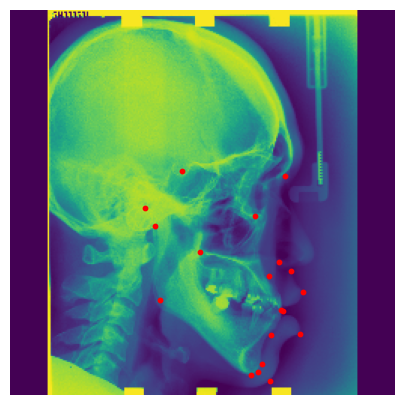

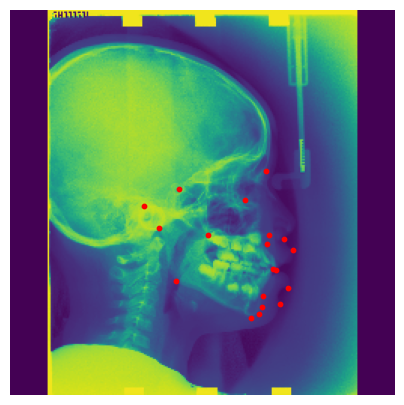

In [ ]:
train_dataset=CephaDataset('train')
test_dataset=CephaDataset('test')


#TODO

img, lm = train_dataset[0]


plt.figure(figsize=(5, 5))
plt.imshow(img[0])
plt.scatter(lm[:,0], lm[:,1], c="red", s=10)
plt.axis("off")
plt.show()

tst_img, tst_lm = test_dataset[1]
plt.figure(figsize=(5,5))
plt.imshow(tst_img[0])
plt.scatter(tst_lm[:,0], tst_lm[:,1], c="red", s=10)
plt.axis("off")
plt.show()

### Task 1: Heatmaps and Landmarks

To obtain a continuous representation for landmarks, we generate a heatmap image (the same size of the image) for each landmark by placing a gaussian curve around the coordinates.
- The function should expect the image  $B \times C \times H \times W$, the landmarks $B\times N \times 2$ as well as the standard deviation and and amplitude of the gaussian as input
- First, generate a  $H\times W \times 2$ grid that spans the size of the whole image using `torch.meshgrid` and `torch.arange` . Since you are working with point coordinates (original bottom left) instead of image coordinates (origin bottom right), you'll need to set `indexing='xy'`. `torch.meshgrid` outputs a tuple that you can then stack with `torch.stack` to obtain the grid.
- Next, calculate the distance between each pixel of the grid and the landmarks. To omit inefficient for loops, use broadcasting: First, view the grid, so you have only one spacial dimension (H*W instead of H,W) and add an artifical batch dimension. Then substract the viewed grid and landmarks, but unsqueeze them appropriately so you then get a Tensor of shape $B \times N \times HW \times 2$ that contains the distances between each pixel and the landmarks.
- Based on the distances you can calculate the gaussian curve:
$$ f(x) = A \exp (-\frac{(x-\mu)^{2}}{2\sigma^{2}}) $$
- Here, x are the coordinates and $\mu$ is the landmark position. Sum over the last dimension after calculating $(x-\mu)^{2}$ to get one singe image instead of one for each direction (this removes the last dimension). Weight with the standard deviation $\sigma$ and the amplitude $A$ to vary the width and height of the gaussian curve.
- You obtain the final heatmap by reshaping the gaussian into the original image's shape.

In [ ]:
def generate_heatmap_from_lms(img: torch.Tensor, lms:torch.Tensor, std_pixel: int, alpha: int) -> torch.Tensor:
    # Images shape: BxCxHxW
    B, _, H, W = img.shape
    # Landmarks shape: BxNx2
    N = lms.shape[1]

    #TODO
    grid_x, grid_y = torch.meshgrid(torch.arange(H, device=device),torch.arange(W, device=device),indexing="xy")
    assert grid_x.shape == (H,W)

    grid = torch.stack([grid_x,grid_y], dim=-1)
    assert grid.shape == (H,W,2)

    grid_viewed = grid.view(-1,2).unsqueeze(0)
    assert grid_viewed.shape == (1, H*W, 2)

    lms = lms.unsqueeze(2).cuda()
    distances = torch.sum((grid_viewed - lms) ** 2, dim = -1)
    assert distances.shape == (B,N,H*W)


    gaussian = alpha * torch.exp(-(distances) / (2 * std_pixel ** 2))
    assert gaussian.shape == (B,N,H*W)

    heatmap = gaussian.view(B,N,H,W)
    assert heatmap.shape == (B,N,H,W)

    return heatmap

# for trying out
trial_lms = torch.randint(0,10,(3,5,2), device=device)
hmp = generate_heatmap_from_lms(img=torch.zeros(3,1,10,10).cuda(), lms=trial_lms, std_pixel=1, alpha=1)

To check if the heatmap is generated correctly, visualise the heatmap for an examplary keypoint and image.
- Generate the heatmap for 1 example image and its landmarks using your implemented method.
- Visualize this example image and 1 example landmark using `plt.imshow` and `plt.scatter`.
- Visualize the corresponding heatmap by overlaying the image with the heatmap. To overlay both images, visualise the heatmap with `plt.imshow` as well, but set the `alpha` value accordingly (and use `cmap='jet'`).
- You can try out different values for the standard deviation and amplitude.

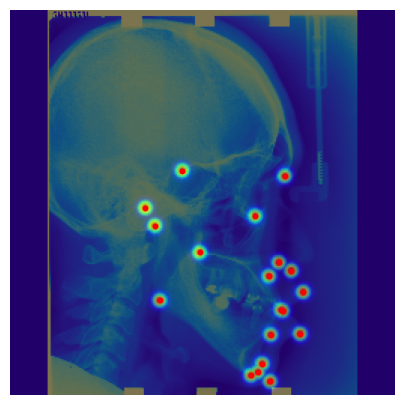

In [ ]:
#TODO
train_dataset=CephaDataset('train')
img, lm = train_dataset[0]

hmp = generate_heatmap_from_lms(img=img.unsqueeze(0), lms=lm.unsqueeze(0), std_pixel=3, alpha=1)
plt.figure(figsize=(5, 5))
plt.imshow(img[0])

hmp_max_values = torch.max(hmp.squeeze(0), dim=0)[0]


plt.imshow(hmp_max_values.cpu(), alpha=0.5, cmap='jet')
plt.scatter(lm[:,0], lm[:,1], c="red", s=10)
plt.axis("off")

plt.show()

When prediciting a heatmap instead of the landmarks directly, we also need a function to get landmarks back from the predicted heatmaps. The following function shall return the coordinate with the heatmaps's maximal value. You can use `torch.argmax` for this.
Tips:
- You do not need separate argmax coordinates for x and y. You can view the image to $B \times N \times HW$ shape before calling `torch.argmax`.
- To get xy coordinates back, you can use the `//` (integer division) and `%` (remainder) operators when dividing with the image width.

In [ ]:
def extract_lms_from_heatmap(heatmap:torch.Tensor) -> torch.Tensor:
    """
    Extract the coordinates of the keypoints from the heatmap.
    :param heatmap: heatmap of shape (B, N, H, W)
    :return: coordinates of the keypoints of shape (B, N, 2)
    """

    B, N, H, W = heatmap.shape
    # TODO
    heatmap_viewed = heatmap.view(B,N,H*W)

    idx = torch.argmax(heatmap_viewed, dim=-1)

    y = idx // W
    x = idx % W
    return torch.stack([x,y], dim=-1)
# This should return True

print("trial_lms:", trial_lms.shape)
print("hmp:", hmp.shape)
pred = extract_lms_from_heatmap(hmp)
print("pred:", pred.shape)
torch.all(trial_lms == extract_lms_from_heatmap(hmp)).item()

trial_lms: torch.Size([3, 5, 2])
hmp: torch.Size([3, 5, 10, 10])
pred: torch.Size([3, 5, 2])


True

### Task 2: Regression

Now that you can get heatmaps from landmarks (and the other way around), build the network that can predict such heatmaps from the given images.

Build the model class `KeypointUNet` that inherits from `nn.Module`. The network should contain two parts: A U-Net feature extractor and a heatmap regressor. Use the following specifications:
- Use the U-Net from monai.networks.nets ([Documentation](https://docs.monai.io/en/stable/networks.html#unet))
- The U-Net should have 64 output channels and a hidden channel sequence of (64, 128, 256, 512).
- The U-Net's stride should always be 2.
- The number of residual units in the U-Net should be 2.
- The U-Nets activation function should be 'leakyrelu'.
- The heatmap regressor maps the feature output of the U-Net to the number of landmarks without any convolutions. The kernel_size should be set to 1 accordingly. The bias should be set to True.
- Don't forget to call the initialisation of the superclass.

Use `summary` to display the network for 19 landmarks. The network should have $6,514,323$ trainable parameters.

In [ ]:
#TODO
class KeyPointNet(nn.Module):
  def __init__(self, num_landmarks):
      super().__init__()

      self.unet = nets.Unet(
          spatial_dims=2,
          in_channels=1,
          out_channels=64,
          channels=(64,128,256,512),
          strides=(2,2,2),
          num_res_units=2,
          act="LEAKYRELU"
      )

      self.regressor = nn.Conv2d(
          in_channels=64,
          out_channels=num_landmarks,
          kernel_size=1,
          bias=True
      )

  def forward(self, x):
    features = self.unet(x)

    heatmaps = self.regressor(features)

    return heatmaps

model = KeyPointNet(19)

summary(model)


Layer (type:depth-idx)                                                                Param #
KeyPointNet                                                                           --
├─UNet: 1-1                                                                           --
│    └─Sequential: 2-1                                                                --
│    │    └─ResidualUnit: 3-1                                                         38,208
│    │    └─SkipConnection: 3-2                                                       6,364,160
│    │    └─Sequential: 3-3                                                           110,720
├─Conv2d: 1-2                                                                         1,235
Total params: 6,514,323
Trainable params: 6,514,323
Non-trainable params: 0

Now, write the training loop.
The following should be initally defined:
- Initialise a model and set it to training mode.
- Initialise the optimizer (use Adam optimizer with a learning rate of 0.001)
- Define a training `DataLoader` with batch size 10 and shuffling enabled.
- Define the criterion as MSELoss.
- Set the hyperparameters: the number of epochs should be 30, the amplitude of the heatmap should be 44 and the standard deviation 8.

For each epoch, load the batches from the dataloader and for each batch do the following:
- Create the ground truth heatmap from the landmarks.
- Call the network on the image to get the predicted heatmap.
- Calculate the loss as the MSE between predicted and ground truth heatmap.
- Reset the gradient of the optimizer
- Perform backpropagation on the loss
- Make one optimizer step

At the end of each epoch
- get the predicted landmarks from the predicted heatmaps for the latest batch
- calculate the landmark error with `tre = torch.linalg.vector_norm(lm - lm_hat, ord=2, dim=-1)`

Choose a useful output during training. For example, instead of `range` use `trange` from tqdm to display a progress bar and print the loss and landmark error after every epoch with `tqdm.write`.
After training the loss should reduce to ~0.1 and the landmark error to ~1px.


In [ ]:
#TODO
from tqdm import trange
train_dataloader = DataLoader(train_dataset, batch_size=10, shuffle=True)

def train_model(model: nn.Module, num_landmarks, num_epochs=30, amp=44, std=8):

  model.to(device)
  optimizer = torch.optim.Adam(model.parameters(), lr=0.001)

  criterion = nn.MSELoss()

  for epoch in trange(num_epochs):

      model.train()

      epoch_loss = 0

      for img, lm in train_dataloader:

        img = img.to(device)
        lm = lm.to(device)

        gt_hmp = generate_heatmap_from_lms(img, lm, std_pixel=std, alpha=amp)

        optimizer.zero_grad()

        hmp = model(img)

        loss = criterion(hmp, gt_hmp)

        loss.backward()

        optimizer.step()

        epoch_loss += loss.item()


      lm_hat = extract_lms_from_heatmap(hmp)

      tre = torch.linalg.vector_norm(lm - lm_hat, ord=2, dim=-1)

      epoch_loss /= len(train_dataloader)
      print(
        f"Epoch {epoch+1}/{num_epochs} "
        f"Loss: {epoch_loss:.4f} "
        f"TRE: {tre.mean().item():.2f}px"
        )

model = KeyPointNet(19)
train_model(model=model, num_landmarks=19)





  3%|▎         | 1/30 [00:09<04:40,  9.66s/it]

Epoch 1/30 Loss: 4.7001 TRE: 24.17px


  7%|▋         | 2/30 [00:19<04:30,  9.66s/it]

Epoch 2/30 Loss: 3.1258 TRE: 20.04px


 10%|█         | 3/30 [00:28<04:19,  9.62s/it]

...

Epoch 28/30 Loss: 0.0963 TRE: 1.10px


 97%|█████████▋| 29/30 [04:18<00:08,  8.84s/it]

Epoch 29/30 Loss: 0.0845 TRE: 1.12px


100%|██████████| 30/30 [04:27<00:00,  8.92s/it]

Epoch 30/30 Loss: 0.0734 TRE: 1.04px


### Task 3: Evaluation
Now, evaluate your network. Use `with torch.no_grad()` when calling the model on the images.
You should get a landmark error of less than 3 pixels on average.

In [ ]:
test_dataloader = DataLoader(test_dataset, batch_size=1, shuffle=False)
model = model.to(device)
model.eval()
all_tre = []
for img, lm in test_dataloader:
    # TODO
    img = img.to(device)
    lm = lm.to(device)

    with torch.no_grad():

      hmp = model(img)

    lm_hat = extract_lms_from_heatmap(hmp)
    tre = torch.linalg.vector_norm(lm - lm_hat, ord=2, dim=-1)
    all_tre.append(tre)
print(f'Landmark error - mean: {round(torch.stack(all_tre).mean().item(),3)}, std: {round(torch.stack(all_tre).std().item(),3)}')



Landmark error - mean: 2.61, std: 2.199


You can compare your results vs. simply predicting the mean landmark position (given below).

In [ ]:
all_train_img = torch.stack([train_dataset[i][0] for i in range(len(train_dataset))])
all_train_lms = torch.stack([train_dataset[i][1] for i in range(len(train_dataset))])

mean_lms = all_train_lms.mean(0)
print(mean_lms.shape)
all_tre = []
for batch in test_dataloader:
    img, lm = batch[:2]
    lm_hat = mean_lms
    tre = torch.linalg.vector_norm(lm - lm_hat, ord=2, dim=-1)
    all_tre.append(tre)
print(f'Landmark error (mean landmark) - mean: {round(torch.stack(all_tre).mean().item(),3)}, std: {round(torch.stack(all_tre).std().item(),3)}')

torch.Size([19, 2])
Landmark error (mean landmark) - mean: 10.126, std: 6.426


Finally, visualise some test case results. Get the predicted heatmaps and landmarks for a test case and plot the image (with `plt.imshow`) alongside both the ground truth and predicted landmarks (with `plt.scatter`). You can use `plt.legend` to differentiate prediction and ground truth.

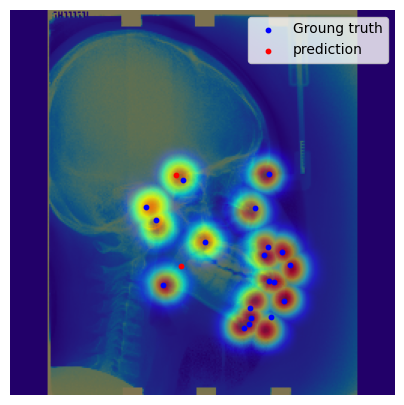

In [ ]:
#TODO
img, lm = test_dataset[0]

img = img.to(device)
lm = lm.to(device)

hmp = model(img.unsqueeze(0))

lm_hat = extract_lms_from_heatmap(hmp)

plt.figure(figsize=(5, 5))
plt.imshow(img[0].cpu())

hmp_max_values = torch.max(hmp.detach().squeeze(0), dim=0)[0]

lm_hat = lm_hat.cpu()
lm = lm.cpu()
plt.imshow(hmp_max_values.cpu(), alpha=0.5, cmap='jet')
plt.scatter(lm[:,0], lm[:,1], c="blue", s=10, label="Groung truth")
plt.scatter(lm_hat[:,0], lm_hat[:,1], c="red", s=10, label="prediction")
plt.axis("off")

plt.legend()

plt.show()